# QTCAD M20 WKB — Result Analysis (심화판)

Transport 2 (Quantum transport — WKB approximation) 튜토리얼(`WKB_current.py`) 결과를
분석합니다. Lead-dot-lead 구조(GaAs, 해석적 포물선 횡방향 구속)에서 좌/우 lead와
가운데 dot 사이의 WKB 터널링 비율을 계산해 순차 터널링(sequential tunneling) 전류를
구합니다.

**이 노트북에서 실제로 수행한 분석 (요약)**
- `.geo` 메시 치수 공식으로 **소자 스케매틱**(측면도: lead-barrier-dot-barrier-lead +
  포물선 횡방향 퍼텐셜)을 직접 재구성 (0절)
- 전 파라미터(포물선 상수, barrier/lead 오프셋, bias, 스윕 범위)의 **선택 의도**를
  스크립트 주석·값에서 그대로 정리 (0절)
- Lead 파동함수에 대해 **WKB 근사식**과 분리형(separable) ansatz 형태를 명시 (1절)
- Coulomb peak 전류에 대해 **순차 터널링 master equation**의 물리적 의미를 설명 (2절)
- Coulomb diamond 지도에 **미분 전도도 정의식**을 명시하고 원본 "WKB 끈" 설정의
  의미를 해석 (3절)
- 모든 그림·표를 `output/analysis_exports/`에 저장 (4절)

---
## 📚 참고 문서
- **QTCAD 공식 튜토리얼** — Transport 2: Quantum transport—WKB approximation
  https://docs.nanoacademic.com/qtcad/tutorials/transport/WKB_current/
- **QTCAD 문서 포털**: https://docs.nanoacademic.com/qtcad/
- 소스 스크립트: `WKB_current.py` (튜토리얼 원본, M20/Reference에 복사)
---

**Base directory**

`C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M20. WKB\Reference`

목차:
0. 소자 스케매틱 + 파라미터 선택 의도
1. Lead 파동함수 (WKB 근사) 확인
2. Coulomb peak 전류 곡선 — 순차 터널링 master equation
3. Coulomb diamond(미분 전도도) 지도
4. 최종 요약


In [1]:
# [동작] 기본 패키지 및 경로 설정
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.image as mpimg
from IPython.display import display

BASE_DIR = Path(
    r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M20. WKB\Reference"
)
OUTPUT_DIR = BASE_DIR / "output"
EXPORT_DIR = OUTPUT_DIR / "analysis_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

FILE_L_WF = OUTPUT_DIR / "L_lead_wf.png"
FILE_R_WF = OUTPUT_DIR / "R_lead_wf.png"
FILE_PEAKS_TXT = OUTPUT_DIR / "coulomb_peaks.txt"
FILE_DIAMOND_NPY = OUTPUT_DIR / "coulomb_diamonds.npy"

ct_e = 1.602176634e-19
ct_hbar = 1.054571817e-34
nm = 1e-9

print("BASE_DIR  :", BASE_DIR)
print("EXPORT_DIR:", EXPORT_DIR)
assert BASE_DIR.exists(), f"Base directory가 없습니다:\n{BASE_DIR}"
assert OUTPUT_DIR.exists(), f"output 폴더가 없습니다:\n{OUTPUT_DIR}"
print("\n[OK] 기본 경로 확인 완료")


BASE_DIR  : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M20. WKB\Reference
EXPORT_DIR: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M20. WKB\Reference\output\analysis_exports

[OK] 기본 경로 확인 완료


In [2]:
# [점검] 파일 inventory
expected_files = {
    "L_lead_wf.png": FILE_L_WF, "R_lead_wf.png": FILE_R_WF,
    "coulomb_peaks.txt": FILE_PEAKS_TXT, "coulomb_diamonds.npy": FILE_DIAMOND_NPY,
}
rows = []
for label, path in expected_files.items():
    rows.append({"file": label, "exists": path.exists(),
                "size_KB": path.stat().st_size / 1024 if path.exists() else np.nan})
inventory_df = pd.DataFrame(rows)
display(inventory_df)
missing = inventory_df.loc[~inventory_df["exists"], "file"].tolist()
if missing:
    print("\n[주의] 없는 파일:", missing)
else:
    print("\n[OK] 분석 대상 파일이 모두 존재합니다.")


,file,exists,size_KB
0,L_lead_wf.png,True,51.938477
1,R_lead_wf.png,True,52.044922
2,coulomb_peaks.txt,True,5.088867
3,coulomb_diamonds.npy,True,174.734375



[OK] 분석 대상 파일이 모두 존재합니다.


## 0. 소자 스케매틱 + 파라미터 선택 의도

`meshes/lead_dot_lead.geo`의 치수 공식(Lx=300, dot_length=190, barrier_length=5,
lead_length=(Lx-dot_length-2*barrier_length)/2=50, Ly=100, Lz=20 nm)과
`WKB_current.py`의 퍼텐셜 설정을 그대로 재구성한 측면 스케매틱입니다.

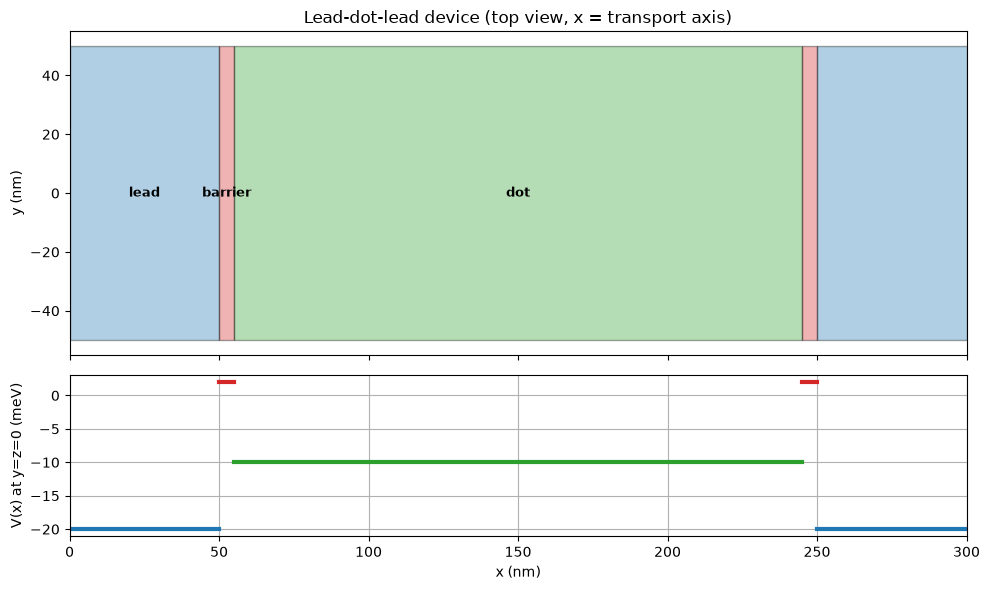

,parameter,intent
0,"Lx=300, dot=190, barrier=5x2, lead=50x2 nm",lead_dot_lead.geo 고정 치수 — 두 lead가 각 50nm로 충분히 ...
1,"Ky=2e-7, Kz=1e-4 (포물선 구속 세기)","Vy,Vz = K/2*(y-y0)^2 형태의 횡방향 조화진동자 포텐셜. Kz>>Ky..."
2,"barrier offset +12 meV, lead offset -10 meV, 전...",barrier가 dot/lead보다 12meV 높아 터널 장벽 형성. lead를 d...
3,num_states=10 (Schrödinger solver),Coulomb peak 전류 계산(many_body_solver_params.num...
4,"junc.setVs(2.5mV), setVd(0), T=1K (Coulomb pea...",저바이어스(linear response) 영역 — 열에너지 kT(1K)~86 µeV...
5,"v_gate_rng: -1~8 mV, 100점 / Coulomb diamond: V...",Coulomb peak 하나가 들어오는 좁은 전압창을 조밀하게(100점) 스캔. d...


In [3]:
# [실험] 소자 스케매틱 재현 (lead_dot_lead.geo 치수 공식 그대로)
Lx, dot_length, barrier_length = 300.0, 190.0, 5.0
lead_length = (Lx - dot_length - 2 * barrier_length) / 2
Ly, Lz = 100.0, 20.0

regions = [
    ("lead", 0, lead_length, "tab:blue", -10e-3),
    ("barrier", lead_length, lead_length + barrier_length, "tab:red", 12e-3),
    ("dot", lead_length + barrier_length, lead_length + barrier_length + dot_length, "tab:green", 0.0),
    ("barrier", lead_length + barrier_length + dot_length,
     lead_length + 2 * barrier_length + dot_length, "tab:red", 12e-3),
    ("lead2", lead_length + 2 * barrier_length + dot_length, Lx, "tab:blue", -10e-3),
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})
for name, x0, x1, color, _ in regions:
    ax1.add_patch(mpatches.Rectangle((x0, -Ly/2), x1 - x0, Ly, fc=color, alpha=0.35, ec="k"))
ax1.set_xlim(0, Lx); ax1.set_ylim(-Ly/2 - 5, Ly/2 + 5)
ax1.set_ylabel("y (nm)")
ax1.set_title("Lead-dot-lead device (top view, x = transport axis)")
for name, x0, x1, color, _ in set((r[0], r[1], r[2], r[3], r[4]) for r in regions):
    pass
labels_done = set()
for name, x0, x1, color, _ in regions:
    label = "lead" if "lead" in name else name
    if label not in labels_done:
        ax1.text((x0 + x1) / 2, 0, label, ha="center", va="center", fontsize=9, fontweight="bold")
        labels_done.add(label)

# Potential profile added in V (uniform shift -1e-2*e applied everywhere in script)
uniform_shift = -1e-2
for name, x0, x1, color, v0 in regions:
    ax2.plot([x0, x1], [(v0 + uniform_shift) * 1e3] * 2, color=color, lw=3)
ax2.set_xlabel("x (nm)"); ax2.set_ylabel("V(x) at y=z=0 (meV)")
ax2.grid(True)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "device_schematic_side_view.png", dpi=150)
plt.show()

param_intent = pd.DataFrame([
    {"parameter": "Lx=300, dot=190, barrier=5x2, lead=50x2 nm",
     "intent": "lead_dot_lead.geo 고정 치수 — 두 lead가 각 50nm로 충분히 길어 WKB lead "
               "파동함수가 점근적(asymptotic) 평면파 형태에 수렴하도록 함"},
    {"parameter": "Ky=2e-7, Kz=1e-4 (포물선 구속 세기)",
     "intent": "Vy,Vz = K/2*(y-y0)^2 형태의 횡방향 조화진동자 포텐셜. Kz>>Ky로 z방향을 "
               "훨씬 세게 가둬 준1차원(quasi-1D) 도선처럼 만듦 — WKB가 x방향 1D 터널링"
               "문제로 분리(separable)되려면 횡방향이 종방향보다 훨씬 강하게 구속돼야 함"},
    {"parameter": "barrier offset +12 meV, lead offset -10 meV, 전역 -10 meV 이동",
     "intent": "barrier가 dot/lead보다 12meV 높아 터널 장벽 형성. lead를 dot보다 10meV "
               "낮춰 전자가 lead에서 dot로 들어갈 때 유리하도록(에너지 사면) 설계. 마지막 "
               "전역 -10meV 이동은 전체 에너지 기준점을 화학퍼텐셜 근처로 맞추는 조정."},
    {"parameter": "num_states=10 (Schrödinger solver)",
     "intent": "Coulomb peak 전류 계산(many_body_solver_params.num_states=1)에는 바닥상태 "
               "1개면 충분하지만, dot 상태 자체는 여러 횡방향 준위를 포함하도록 넉넉히 "
               "10개 요청 — WKB lead의 n1=n2=1 (lead 쪽은 가장 낮은 횡방향 준위만 사용)"},
    {"parameter": "junc.setVs(2.5mV), setVd(0), T=1K (Coulomb peak 계산)",
     "intent": "저바이어스(linear response) 영역 — 열에너지 kT(1K)~86 µeV보다는 크고 "
               "dot 준위 간격보다는 작은 수준의 source bias로, 선형 전도 영역에서 Coulomb "
               "peak 모양을 왜곡 없이 봄"},
    {"parameter": "v_gate_rng: -1~8 mV, 100점 / Coulomb diamond: Vg -1~8mV x Vs ±10mV, 150x150",
     "intent": "Coulomb peak 하나가 들어오는 좁은 전압창을 조밀하게(100점) 스캔. diamond는 "
               "source/drain bias까지 넓혀 2차원 안정성 다이어그램 형태로 봄 (M06의 CSD와 "
               "같은 발상)."},
])
display(param_intent)
param_intent.to_csv(EXPORT_DIR / "parameter_intent.csv", index=False)


## 1. Lead 파동함수 (WKB 근사) 확인

**물리 모델**: `WKBLead`는 횡방향(y,z)은 조화진동자 고유상태로 두고, 종방향(x)은
WKB(준고전) 근사로 풉니다 — 전체 파동함수는 분리형(separable) ansatz:
$$
\psi(x,y,z) \approx \phi_\mathrm{WKB}(x)\, \chi_{n_y}(y)\, \chi_{n_z}(z)
$$
여기서 $\chi_n$은 포물선 퍼텐셜 $V=\tfrac{1}{2}K(r-r_0)^2$의 조화진동자 고유함수이고
(이 튜토리얼은 lead 쪽에서 가장 낮은 준위 $n_y=n_z=1$만 사용), $\phi_\mathrm{WKB}$는
표준 WKB 위상적분입니다:
$$
\phi_\mathrm{WKB}(x) \propto \frac{1}{\sqrt{k(x)}}\exp\!\left(\pm i\int^x k(x')\,dx'\right),
\quad k(x)=\frac{\sqrt{2m^*(E-V(x))}}{\hbar}
$$
($E<V(x)$인 고전적으로 금지된 영역, 즉 barrier 안에서는 $k\to i\kappa$가 되어 지수
감쇠). $E=5$ meV에서 좌/우 lead 파동함수를 그대로 표시합니다.

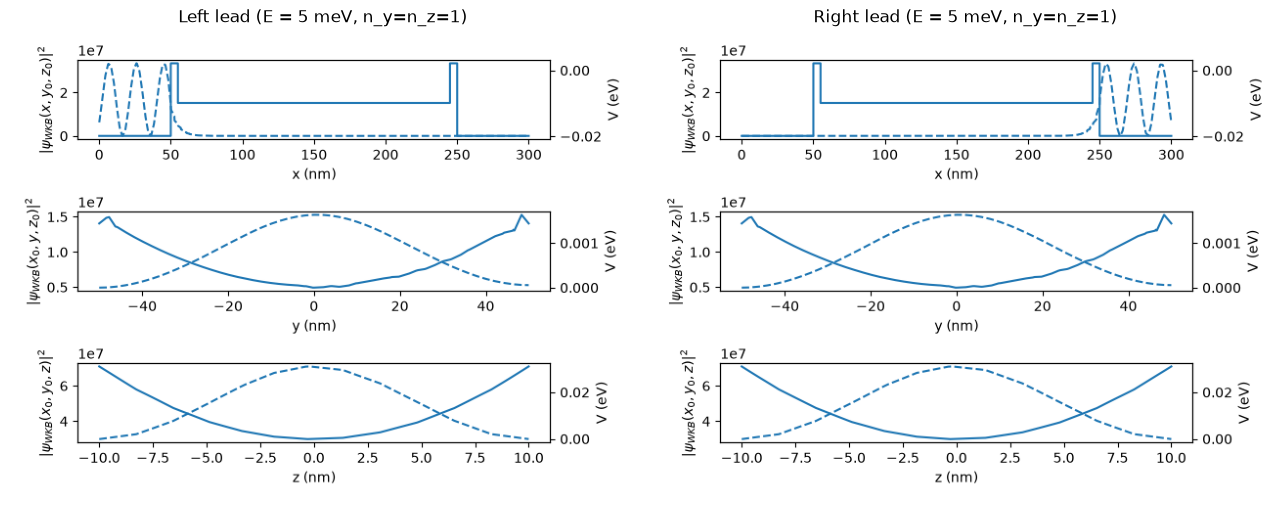


[해석] barrier 영역(0절 스케매틱에서 V=+2meV, 전역이동 후)에서 E=5meV 전자는 고전적으로 허용(E>V)되어 진동하는 파동함수를 보이거나, 만약 유효 장벽이 E보다 높다면 지수적으로 감쇠하는 터널링 파동함수를 보여야 합니다. 좌/우가 대칭이면 barrier·lead 설정이 양쪽에 동일하게 적용됐다는 뜻입니다.


In [4]:
# [실험] 좌/우 lead 파동함수 이미지 표시
fig, axs = plt.subplots(1, 2, figsize=(13, 5))
for ax, f_, title in zip(axs, (FILE_L_WF, FILE_R_WF), ("Left lead", "Right lead")):
    ax.imshow(mpimg.imread(f_))
    ax.axis("off")
    ax.set_title(f"{title} (E = 5 meV, n_y=n_z=1)")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "lead_wavefunctions_comparison.png", dpi=150)
plt.show()

print(
    "\n[해석] barrier 영역(0절 스케매틱에서 V=+2meV, 전역이동 후)에서 E=5meV 전자는 "
    "고전적으로 허용(E>V)되어 진동하는 파동함수를 보이거나, 만약 유효 장벽이 E보다 "
    "높다면 지수적으로 감쇠하는 터널링 파동함수를 보여야 합니다. 좌/우가 대칭이면 "
    "barrier·lead 설정이 양쪽에 동일하게 적용됐다는 뜻입니다."
)


## 2. Coulomb Peak 전류 곡선 — 순차 터널링 Master Equation

**물리 모델**: `seq_tunnel_curr`는 dot의 many-body 스펙트럼을 대각화하고, dot-lead
결합에 대한 Fermi 황금률 비율 $\Gamma_{i\to j}$(WKB로 구한 lead-dot 중첩이
투과율을 결정)을 구성해 정상상태 master equation을
$$
\sum_j \big(\Gamma_{j\to i}\,p_j - \Gamma_{i\to j}\,p_i\big) = 0, \qquad
\sum_i p_i = 1
$$
풀어 점유확률 $p_i$를 얻고, 전류는 한쪽 lead를 가로지르는 순 터널링 비율의 합
$I = e\sum_i \big(\Gamma^{L}_{i\to}\,p_{\to} - \Gamma^{L}_{\to i}\,p_i\big)$로
계산합니다 (표준 sequential-tunneling quantum-dot transport 이론).

,V_gate_V,I_A,I_nA
count,100.000000,1.000000e+02,1.000000e+02
mean,0.003500,-3.800119e-10,3.800119e-01
std,0.002637,5.609255e-10,5.609255e-01
min,-0.001000,-3.404461e-09,4.163417e-16
25%,0.001250,-4.808255e-10,8.243817e-05
50%,0.003500,-2.621122e-10,2.621122e-01
75%,0.005750,-8.243817e-14,4.808255e-01
max,0.008000,-4.163417e-25,3.404461e+00


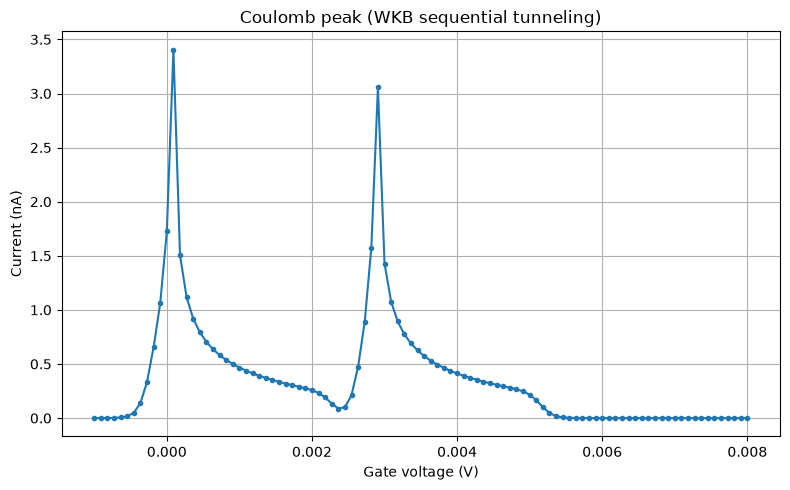


최대 |전류| 지점: V_gate = 0.00009 V, I = -3.404e-09 A
반치전폭(FWHM) 근사: 2.909 mV

[해석] 전류가 특정 게이트 전압 근처에서 뾰족하게 솟아오르는 모양이면 전형적인 Coulomb peak입니다. 피크 위치는 dot 안의 에너지 준위가 source/drain 화학 퍼텐셜 창과 맞춰지는 지점이며, 피크의 높이·폭(FWHM)은 WKB 터널링 비율(barrier 투과율)과 온도(T=1K, kT~86µeV)가 함께 결정합니다 — 저온 극한에서는 폭이 주로 결합세기(Γ)로, 고온에서는 열적 broadening(~3.5kT)으로 지배됩니다.


In [5]:
# [동작] Coulomb peak 데이터 로드
peaks = np.loadtxt(FILE_PEAKS_TXT)
v_gate, I = peaks[:, 0], peaks[:, 1]

peaks_df = pd.DataFrame({"V_gate_V": v_gate, "I_A": I, "I_nA": -I / 1e-9})
display(peaks_df.describe())
peaks_df.to_csv(EXPORT_DIR / "coulomb_peaks_data.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(v_gate, -I / 1e-9, "-o", ms=3)
ax.set_xlabel("Gate voltage (V)")
ax.set_ylabel("Current (nA)")
ax.set_title("Coulomb peak (WKB sequential tunneling)")
ax.grid(True)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "coulomb_peaks.png", dpi=150)
plt.show()

i_peak = np.argmax(np.abs(I))
# FWHM 추정
half_max = np.abs(I).max() / 2
above = np.where(np.abs(I) >= half_max)[0]
fwhm_mV = (v_gate[above[-1]] - v_gate[above[0]]) * 1e3 if len(above) > 1 else np.nan

print(f"\n최대 |전류| 지점: V_gate = {v_gate[i_peak]:.5f} V, I = {I[i_peak]:.3e} A")
print(f"반치전폭(FWHM) 근사: {fwhm_mV:.3f} mV")
print(
    "\n[해석] 전류가 특정 게이트 전압 근처에서 뾰족하게 솟아오르는 모양이면 전형적인 "
    "Coulomb peak입니다. 피크 위치는 dot 안의 에너지 준위가 source/drain 화학 퍼텐셜 창과 "
    "맞춰지는 지점이며, 피크의 높이·폭(FWHM)은 WKB 터널링 비율(barrier 투과율)과 "
    "온도(T=1K, kT~86µeV)가 함께 결정합니다 — 저온 극한에서는 폭이 주로 결합세기(Γ)로, "
    "고온에서는 열적 broadening(~3.5kT)으로 지배됩니다."
)


## 3. Coulomb Diamond(미분 전도도) 지도

게이트 전압과 source/drain 전압(대칭 bias) 평면에서 미분 전도도
$g(V_g,V_s) = |\partial I_{left}/\partial V_{gate}|_{V_s}$ (유한차분으로 근사)를 봅니다.
**원본 스크립트는 이 단계에서 `junc.WKB=False`로 설정** — 즉 모든 전이에 균일한
터널링 비율을 가정하고 시각화만을 목적으로 계산합니다(WKB 투과율의 게이트/에너지
의존성을 반영하지 않음).

diamond 배열 크기: (150, 149)  (V_gate 150점 x V_source 149점, 차분이라 1열 감소)
값 범위: 0.000e+00 ~ 8.115e-20


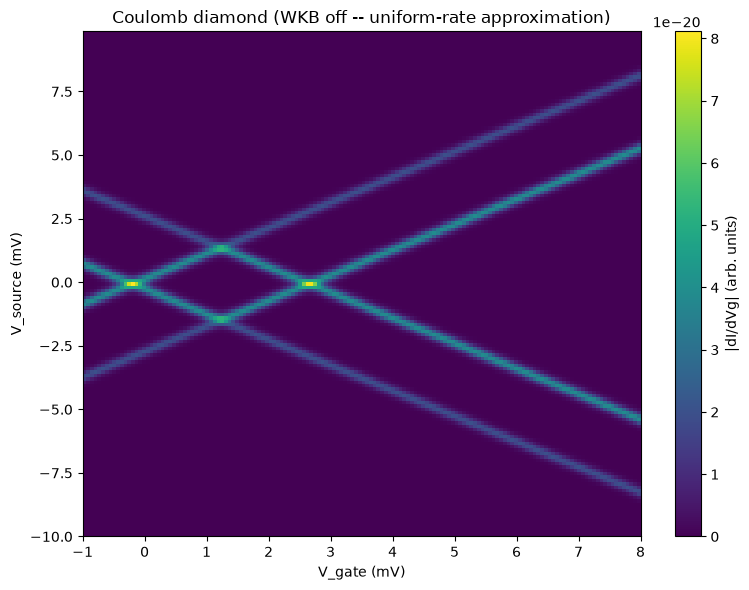


[주의] 이 지도는 WKB를 끄고(모든 전이에 균일한 터널링 비율 가정) 시각화 목적으로만 계산한 것입니다. 실제 WKB 터널링 비율(barrier 투과율의 에너지 의존성)을 반영하지 않으므로, 다이아몬드 모양·경계선 기울기로부터 lever arm을 정량적으로 추정하는 작업(M04/M13에서 한 것과 같은 2-level 피팅)은 이 데이터 그대로는 할 수 없습니다 — WKB를 켠 채로 같은 스윕을 다시 돌려야 정량 분석이 가능합니다.


In [6]:
# [점검] Coulomb diamond 지도 불러오기
diam = np.load(FILE_DIAMOND_NPY)
print(f"diamond 배열 크기: {diam.shape}  (V_gate 150점 x V_source 149점, 차분이라 1열 감소)")
print(f"값 범위: {diam.min():.3e} ~ {diam.max():.3e}")

v_gate_rng = np.linspace(-0.001, 0.008, num=150)
v_left_rng = np.linspace(-0.01, 0.01, num=150)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(
    diam.T, origin="lower", aspect="auto", cmap="viridis",
    extent=[v_gate_rng[0]*1e3, v_gate_rng[-1]*1e3, v_left_rng[0]*1e3, v_left_rng[-2]*1e3],
)
fig.colorbar(im, ax=ax, label="|dI/dVg| (arb. units)")
ax.set_xlabel("V_gate (mV)"); ax.set_ylabel("V_source (mV)")
ax.set_title("Coulomb diamond (WKB off -- uniform-rate approximation)")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "coulomb_diamonds.png", dpi=150)
plt.show()

diam_df = pd.DataFrame(diam)
diam_df.to_csv(EXPORT_DIR / "coulomb_diamonds_raw.csv", index=False, header=False)

print(
    "\n[주의] 이 지도는 WKB를 끄고(모든 전이에 균일한 터널링 비율 가정) 시각화 목적으로만 "
    "계산한 것입니다. 실제 WKB 터널링 비율(barrier 투과율의 에너지 의존성)을 반영하지 "
    "않으므로, 다이아몬드 모양·경계선 기울기로부터 lever arm을 정량적으로 추정하는 "
    "작업(M04/M13에서 한 것과 같은 2-level 피팅)은 이 데이터 그대로는 할 수 없습니다 — "
    "WKB를 켠 채로 같은 스윕을 다시 돌려야 정량 분석이 가능합니다."
)


## 4. 최종 요약

In [7]:
# [점검] 핵심 결과 요약
print("=" * 90)
print("QTCAD M20 WKB — ANALYSIS SUMMARY (심화판)")
print("=" * 90)
print(f"Device footprint             : Lx={Lx:.0f} nm (lead {lead_length:.0f} + barrier "
      f"{barrier_length:.0f} + dot {dot_length:.0f} + barrier {barrier_length:.0f} + lead {lead_length:.0f})")
print(f"Transverse confinement        : Ky={2e-7:.1e}, Kz={1e-4:.1e} (quasi-1D, Kz >> Ky)")
print(f"Gate voltage sweep (peaks)    : {v_gate.min():.4f} - {v_gate.max():.4f} V ({len(v_gate)} points)")
print(f"Current range                  : {I.min():.3e} - {I.max():.3e} A")
print(f"Peak location / FWHM           : V_gate = {v_gate[i_peak]:.5f} V, FWHM ~ {fwhm_mV:.3f} mV")
print(f"Coulomb diamond grid            : {diam.shape[0]} x {diam.shape[1]} points (WKB off)")
print(f"Analysis exports                : {EXPORT_DIR}")
print("=" * 90)


QTCAD M20 WKB — ANALYSIS SUMMARY (심화판)
Device footprint             : Lx=300 nm (lead 50 + barrier 5 + dot 190 + barrier 5 + lead 50)
Transverse confinement        : Ky=2.0e-07, Kz=1.0e-04 (quasi-1D, Kz >> Ky)
Gate voltage sweep (peaks)    : -0.0010 - 0.0080 V (100 points)
Current range                  : -3.404e-09 - -4.163e-25 A
Peak location / FWHM           : V_gate = 0.00009 V, FWHM ~ 2.909 mV
Coulomb diamond grid            : 150 x 149 points (WKB off)
Analysis exports                : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M20. WKB\Reference\output\analysis_exports


## 해석 주의사항

- Coulomb peak 전류는 WKB 근사로 barrier 투과율을 계산한 순차 터널링(sequential
  tunneling) 결과입니다. 저바이어스($V_s=2.5$ mV, $V_d=0$)에서의 선형 응답 영역 근사입니다.
- Coulomb diamond 지도는 `junc.WKB = False`로 WKB를 끄고 균일 터널링 비율을 가정한
  시각화용 계산입니다 — 실제 WKB 투과율을 반영하지 않으므로 다이아몬드 경계의 기울기로
  lever arm 등을 정량적으로 추정하는 데는 쓸 수 없습니다.
- 이 튜토리얼의 dot은 GaAs 포물선 구속 모델(해석적 Vy, Vz)이며, 우리 Si/SiGe 기준 소자의
  실제 Poisson 정전위가 아닙니다. CSD 해석(M06)에 바로 적용하려면 barrier 전압 의존
  WKB 투과율을 우리 소자의 실제 barrier 포텐셜로부터 다시 추출해야 합니다.
